# Step 1 — Data Preparation


In [1]:
# ============================================================
#   CELL 1 — RUN THIS EVERY SESSION
# ============================================================
import os, torch
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Paths
BASE      = "/content/drive/MyDrive/chest_xray_project"
DATA_PATH = f"{BASE}/data"
WEIGHTS   = f"{BASE}/weights"
REPORTS   = f"{BASE}/reports"
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create folders if they don't exist (safe to re-run)
os.makedirs(DATA_PATH, exist_ok=True)
os.makedirs(WEIGHTS,   exist_ok=True)
os.makedirs(REPORTS,   exist_ok=True)

print(f"✅ Drive  : Mounted")
print(f"✅ Device : {DEVICE}")
print(f"✅ Base   : {BASE}")
print(f"✅ Folders: {os.listdir(BASE)}")

Mounted at /content/drive
✅ Drive  : Mounted
✅ Device : cuda
✅ Base   : /content/drive/MyDrive/chest_xray_project
✅ Folders: ['data', 'weights', 'reports']


In [2]:
# ============================================================
#   CELL 2 — DOWNLOAD & LOCATE DATASET
# ============================================================
import kagglehub, os

# Download dataset (caches in /root/.cache/kaggle — no Drive needed)
print("⏳ Downloading COVID-19 Radiography Database...")
dataset_path = kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database")
print(f"✅ Raw Dataset Path: {dataset_path}")

# Check what's inside
print(f"\n📁 Initial Contents: {os.listdir(dataset_path)}")

# Fix nested folder if present
if "COVID-19_Radiography_Dataset" in os.listdir(dataset_path):
    dataset_path = os.path.join(dataset_path, "COVID-19_Radiography_Dataset")
    print(f"📂 Went one level deeper...")

# Final path
print(f"\n✅ Final Dataset Path: {dataset_path}")
print(f"📁 Final Contents: {os.listdir(dataset_path)}")

# Update DATA_PATH to point here
DATA_PATH = dataset_path

# Class-wise image count
print("\n📊 Class Image Counts:")
classes = [f for f in os.listdir(DATA_PATH) if os.path.isdir(os.path.join(DATA_PATH, f))]
for cls in sorted(classes):
    img_folder = os.path.join(DATA_PATH, cls, "images")
    if os.path.exists(img_folder):
        print(f"   {cls}: {len(os.listdir(img_folder))} images")

⏳ Downloading COVID-19 Radiography Database...
Using Colab cache for faster access to the 'covid19-radiography-database' dataset.
✅ Raw Dataset Path: /kaggle/input/covid19-radiography-database

📁 Initial Contents: ['COVID-19_Radiography_Dataset']
📂 Went one level deeper...

✅ Final Dataset Path: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset
📁 Final Contents: ['Lung_Opacity.metadata.xlsx', 'Normal.metadata.xlsx', 'README.md.txt', 'COVID.metadata.xlsx', 'Normal', 'Lung_Opacity', 'Viral Pneumonia.metadata.xlsx', 'Viral Pneumonia', 'COVID']

📊 Class Image Counts:
   COVID: 3616 images
   Lung_Opacity: 6012 images
   Normal: 10192 images
   Viral Pneumonia: 1345 images


In [5]:
# ============================================================
#   CELL 3 (FIXED) — DATA LOADING WITH AUGMENTATION
# ============================================================
import os, torch
from PIL import Image
from torchvision import transforms
from torch.utils.data import DataLoader, random_split

# ── Transforms ───────────────────────────────────────────────
train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ── Custom Dataset (images/ only, no masks) ───────────────────
class COVIDDataset(torch.utils.data.Dataset):
    def __init__(self, root, transform=None):
        self.samples   = []
        self.transform = transform
        self.classes   = sorted([
            d for d in os.listdir(root)
            if os.path.isdir(os.path.join(root, d)) and "mask" not in d.lower()
        ])
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        for cls in self.classes:
            img_dir = os.path.join(root, cls, "images")
            if not os.path.exists(img_dir):
                img_dir = os.path.join(root, cls)
            for fname in os.listdir(img_dir):
                if fname.lower().endswith((".png", ".jpg", ".jpeg")):
                    self.samples.append((os.path.join(img_dir, fname), self.class_to_idx[cls]))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, label

# ── Build Dataset & Splits ────────────────────────────────────
full_dataset = COVIDDataset(root=DATA_PATH, transform=train_transforms)
CLASS_NAMES  = full_dataset.classes
NUM_CLASSES  = len(CLASS_NAMES)

total      = len(full_dataset)
train_size = int(0.8 * total)
val_size   = int(0.1 * total)
test_size  = total - train_size - val_size

train_set, val_set, test_set = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# ── Attractive Output ─────────────────────────────────────────
from collections import Counter

# Count per class
label_counts = Counter([s[1] for s in full_dataset.samples])

print("╔══════════════════════════════════════════════════════╗")
print("║         🫁  COVID-19 RADIOGRAPHY DATASET             ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  📁 Path     : ...{DATA_PATH[-35:]}  ║")
print(f"║  🖼️  Total    : {total:,} images{' ' * (28 - len(str(total)))}║")
print(f"║  🎯 Classes  : {NUM_CLASSES}{' ' * 37}║")
print("╠══════════════════════════════════════════════════════╣")
print("║  CLASS DISTRIBUTION                                  ║")

bar_max = 20
for cls, idx in full_dataset.class_to_idx.items():
    count    = label_counts[idx]
    bar_len  = int((count / max(label_counts.values())) * bar_max)
    bar      = "█" * bar_len + "░" * (bar_max - bar_len)
    pct      = count / total * 100
    print(f"║  {cls:<17} {bar} {count:>5} ({pct:4.1f}%)  ║")

print("╠══════════════════════════════════════════════════════╣")
print("║  SPLIT SUMMARY                                       ║")
print(f"║  🏋️  Train   : {train_size:>6,} images → {len(train_loader):>4} batches          ║")
print(f"║  🔍 Val     : {val_size:>6,} images → {len(val_loader):>4} batches          ║")
print(f"║  🧪 Test    : {test_size:>6,} images → {len(test_loader):>4} batches          ║")
print("╠══════════════════════════════════════════════════════╣")

# Sanity check batch
images, labels = next(iter(train_loader))
print(f"║  📦 Batch   : {str(list(images.shape)):<39}║")
print(f"║  ⚡ Device  : {str(DEVICE):<39}║")
print("╚══════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════╗
║         🫁  COVID-19 RADIOGRAPHY DATASET             ║
╠══════════════════════════════════════════════════════╣
║  📁 Path     : ...tabase/COVID-19_Radiography_Dataset  ║
║  🖼️  Total    : 21,165 images                       ║
║  🎯 Classes  : 4                                     ║
╠══════════════════════════════════════════════════════╣
║  CLASS DISTRIBUTION                                  ║
║  COVID             ███████░░░░░░░░░░░░░  3616 (17.1%)  ║
║  Lung_Opacity      ███████████░░░░░░░░░  6012 (28.4%)  ║
║  Normal            ████████████████████ 10192 (48.2%)  ║
║  Viral Pneumonia   ██░░░░░░░░░░░░░░░░░░  1345 ( 6.4%)  ║
╠══════════════════════════════════════════════════════╣
║  SPLIT SUMMARY                                       ║
║  🏋️  Train   : 16,932 images →  530 batches          ║
║  🔍 Val     :  2,116 images →   67 batches          ║
║  🧪 Test    :  2,117 images →   67 batches          ║
╠════════════════════════════

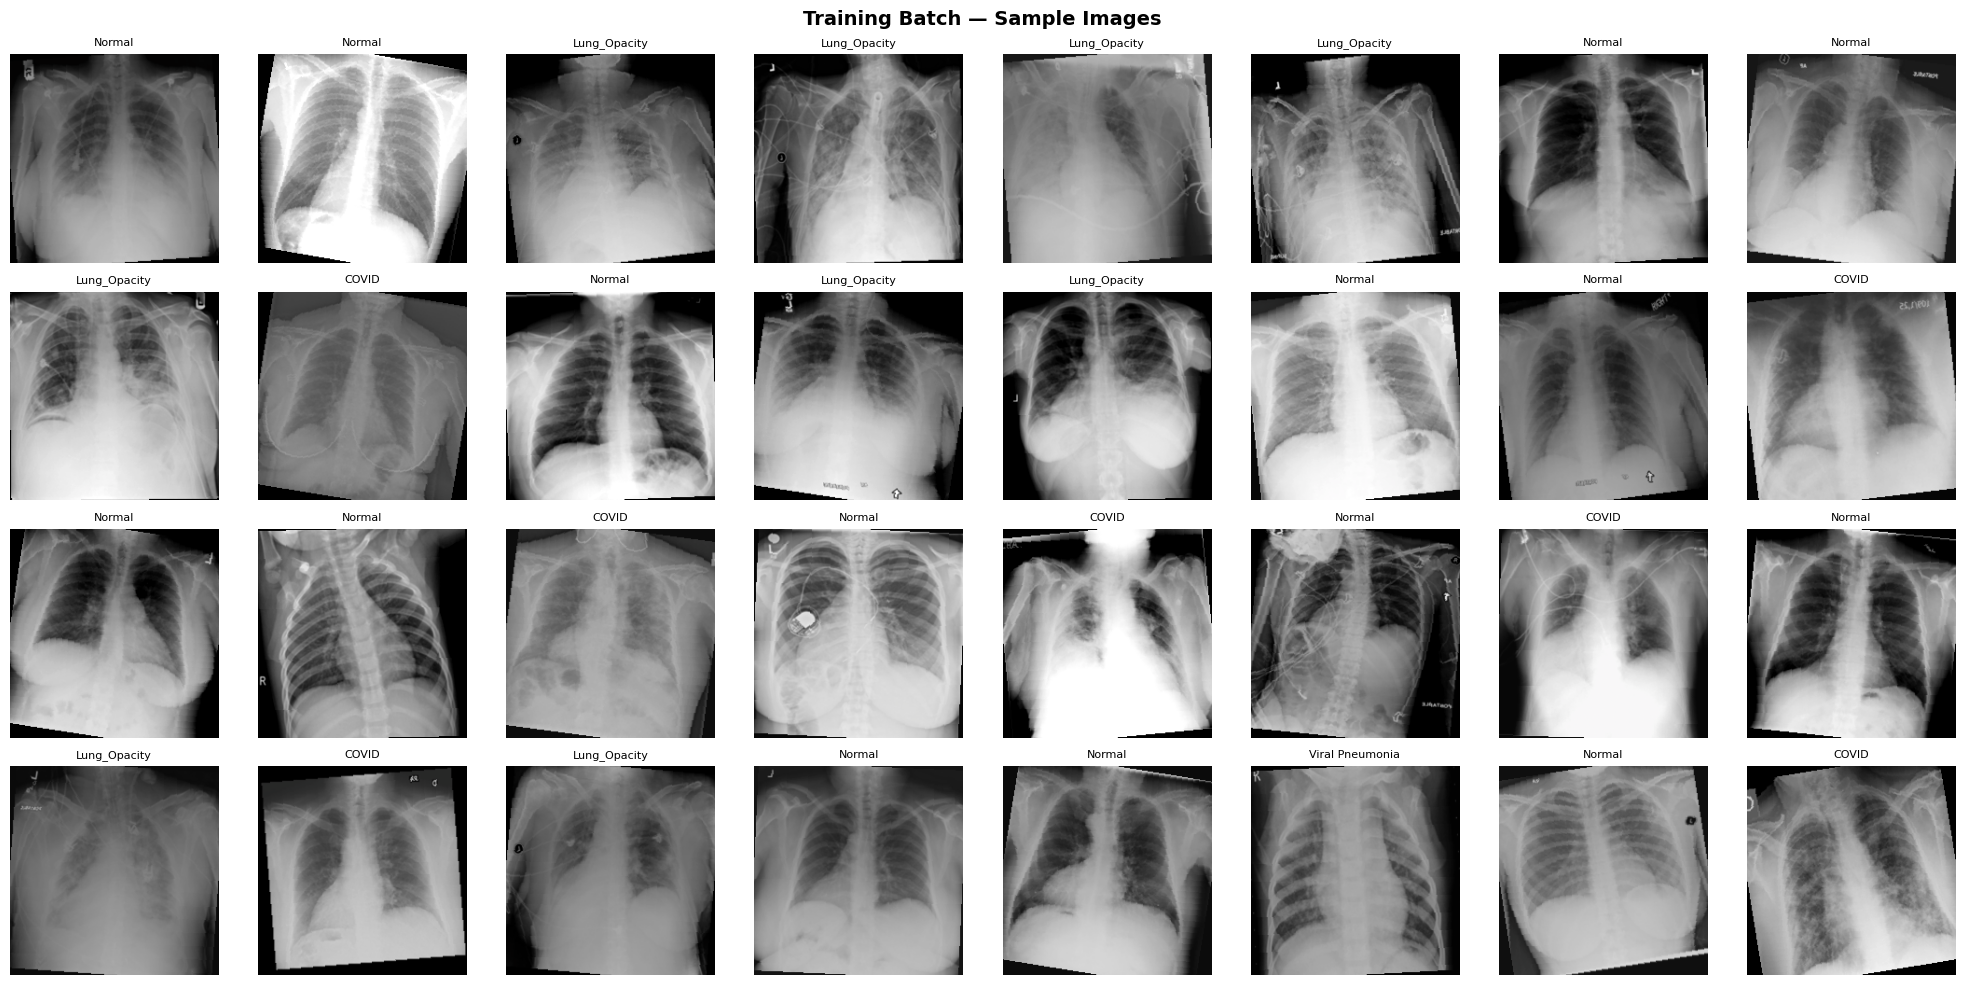

╔══════════════════════════════════════════════════════╗
║       🖼️   BATCH VISUALISATION COMPLETE              ║
╠══════════════════════════════════════════════════════╣
║  📦 Images shown : 32  (4 rows × 8 cols)            ║
║  📐 Image shape  : [3, 224, 224]              ║
║  🎨 Class labels shown above each image              ║
╠══════════════════════════════════════════════════════╣
║  💾 Saved → reports/batch_visualisation.png         ║
╚══════════════════════════════════════════════════════╝


In [8]:
# ============================================================
#   CELL 4 — VISUALISE A BATCH OF TRAINING IMAGES
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return torch.clamp(tensor * std + mean, 0, 1)

# Grab one batch
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(4, 8, figsize=(20, 10))
fig.suptitle("Training Batch — Sample Images", fontsize=14, fontweight="bold")

for i, ax in enumerate(axes.flat):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img, cmap="gray")
    ax.set_title(CLASS_NAMES[labels[i].item()], fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.savefig(f"{REPORTS}/batch_visualisation.png", dpi=120, bbox_inches="tight")
plt.show()

print("╔══════════════════════════════════════════════════════╗")
print("║       🖼️   BATCH VISUALISATION COMPLETE              ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  📦 Images shown : 32  (4 rows × 8 cols)            ║")
print(f"║  📐 Image shape  : {list(images[0].shape)}              ║")
print("║  🎨 Class labels shown above each image              ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  💾 Saved → reports/batch_visualisation.png         ║")
print("╚══════════════════════════════════════════════════════╝")

In [9]:
# ============================================================
#   CELL 5 — MODEL DEFINITIONS
#   ResNet50 | ResNet101 | DenseNet121
# ============================================================
import torch.nn as nn
from torchvision import models

def build_resnet50(num_classes=NUM_CLASSES):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(model.fc.in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, num_classes)
    )
    return model.to(DEVICE)

def build_resnet101(num_classes=NUM_CLASSES):
    model = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(model.fc.in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, num_classes)
    )
    return model.to(DEVICE)

def build_densenet121(num_classes=NUM_CLASSES):
    model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, num_classes)
    )
    return model.to(DEVICE)

# ── Build all three ───────────────────────────────────────────
MODEL_REGISTRY = {
    "ResNet50"    : build_resnet50(),
    "ResNet101"   : build_resnet101(),
    "DenseNet121" : build_densenet121(),
}

# ── Output ────────────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════════════╗")
print("║          🧠  MODEL DEFINITIONS — TRANSFER LEARNING           ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  {'Model':<14} {'Total Params':>14} {'Trainable':>12} {'Frozen %':>10}  ║")
print("╠══════════════════════════════════════════════════════════════╣")

for name, model in MODEL_REGISTRY.items():
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen_pct = 100 * (1 - trainable / total)
    print(f"║  {name:<14} {total:>14,} {trainable:>12,} {frozen_pct:>9.1f}%  ║")

print("╠══════════════════════════════════════════════════════════════╣")
print("║  🏗️  Backbone  : Frozen (ImageNet pretrained weights)        ║")
print("║  🎯 Head       : Dropout → Linear(256) → ReLU → Linear(4)   ║")
print(f"║  ⚡ Device     : {str(DEVICE):<46}║")
print("╚══════════════════════════════════════════════════════════════╝")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 200MB/s]


Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth


100%|██████████| 171M/171M [00:01<00:00, 170MB/s]


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 148MB/s]

╔══════════════════════════════════════════════════════════════╗
║          🧠  MODEL DEFINITIONS — TRANSFER LEARNING           ║
╠══════════════════════════════════════════════════════════════╣
║  Model            Total Params    Trainable   Frozen %  ║
╠══════════════════════════════════════════════════════════════╣
║  ResNet50           24,033,604      525,572      97.8%  ║
║  ResNet101          43,025,732      525,572      98.8%  ║
║  DenseNet121         7,217,284      263,428      96.4%  ║
╠══════════════════════════════════════════════════════════════╣
║  🏗️  Backbone  : Frozen (ImageNet pretrained weights)        ║
║  🎯 Head       : Dropout → Linear(256) → ReLU → Linear(4)   ║
║  ⚡ Device     : cuda                                          ║
╚══════════════════════════════════════════════════════════════╝


In [11]:
# ============================================================
#   CELL 6 — TRAINING & EVALUATION FUNCTIONS (WITH FINE-TUNE)
# ============================================================
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
import time, copy

# ── Hyperparameters ───────────────────────────────────────────
EPOCHS_HEAD   = 5       # Stage 1 — head only
EPOCHS_FINETUNE = 5     # Stage 2 — full model
LR_HEAD       = 1e-3    # higher LR for new head
LR_FINETUNE   = 1e-5    # very low LR for pretrained backbone
STEP_SIZE     = 3
GAMMA         = 0.5


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)
    return running_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            correct      += (outputs.argmax(1) == labels).sum().item()
            total        += labels.size(0)
    return running_loss / total, correct / total


def run_stage(name, stage, model, epochs, lr):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )
    scheduler = StepLR(optimizer, step_size=STEP_SIZE, gamma=GAMMA)
    history   = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}
    best_acc  = 0.0
    best_wts  = copy.deepcopy(model.state_dict())
    start     = time.time()

    print("╔══════════════════════════════════════════════════════════════════╗")
    print(f"║  {stage}  :  {name:<52}║")
    print(f"║  📋 Epochs : {epochs}   📐 LR : {lr:<42}║")
    print("╠════════╦══════════════╦══════════════╦══════════╦══════════╦═════╣")
    print("║ Epoch  ║  Train Loss  ║   Val Loss   ║ Train Acc║  Val Acc ║     ║")
    print("╠════════╬══════════════╬══════════════╬══════════╬══════════╬═════╣")

    for epoch in range(1, epochs + 1):
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        v_loss, v_acc = evaluate(model, val_loader, criterion)
        scheduler.step()

        history["train_loss"].append(t_loss)
        history["val_loss"].append(v_loss)
        history["train_acc"].append(t_acc)
        history["val_acc"].append(v_acc)

        flag = "⭐" if v_acc > best_acc else "  "
        if v_acc > best_acc:
            best_acc = v_acc
            best_wts = copy.deepcopy(model.state_dict())

        print(f"║  {epoch:>3}/{epochs}  ║  {t_loss:>8.4f}    ║  {v_loss:>8.4f}    ║"
              f"  {t_acc*100:>5.2f}%  ║  {v_acc*100:>5.2f}%  ║ {flag} ║")

    elapsed = time.time() - start
    model.load_state_dict(best_wts)
    print("╠════════╩══════════════╩══════════════╩══════════╩══════════╩═════╣")
    print(f"║  ✅ Best Val Acc : {best_acc*100:.2f}%   ⏱️  Time : {elapsed:.1f}s{' '*25}║")
    print("╚══════════════════════════════════════════════════════════════════╝\n")

    return model, history, best_acc


def train_model(name, model):
    all_history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}

    # ── Stage 1: Train head only ──────────────────────────────
    model, h1, acc1 = run_stage(
        name, "🧊 STAGE 1 — HEAD ONLY (Backbone Frozen)",
        model, EPOCHS_HEAD, LR_HEAD
    )
    for k in all_history: all_history[k] += h1[k]

    # ── Stage 2: Unfreeze & fine-tune ─────────────────────────
    for param in model.parameters():
        param.requires_grad = True

    model, h2, acc2 = run_stage(
        name, "🔥 STAGE 2 — FINE-TUNE (Full Model Unfrozen)",
        model, EPOCHS_FINETUNE, LR_FINETUNE
    )
    for k in all_history: all_history[k] += h2[k]

    best_final = max(acc1, acc2)
    return model, all_history, best_final


print("╔══════════════════════════════════════════════════════╗")
print("║    ✅  TRAINING FUNCTIONS READY (2-STAGE)            ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  🧊 Stage 1 — Head Only                             ║")
print(f"║     Epochs : {EPOCHS_HEAD}   LR : {LR_HEAD:<31}║")
print(f"║  🔥 Stage 2 — Full Fine-Tune                        ║")
print(f"║     Epochs : {EPOCHS_FINETUNE}   LR : {LR_FINETUNE:<31}║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  📉 Loss      : CrossEntropyLoss                    ║")
print(f"║  ⚙️  Optimizer : Adam                                ║")
print(f"║  📉 Scheduler : StepLR (step={STEP_SIZE}, γ={GAMMA})            ║")
print("╠══════════════════════════════════════════════════════╣")
print("║  Functions : train_one_epoch() │ evaluate()          ║")
print("║            : run_stage()       │ train_model()       ║")
print("╚══════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════╗
║    ✅  TRAINING FUNCTIONS READY (2-STAGE)            ║
╠══════════════════════════════════════════════════════╣
║  🧊 Stage 1 — Head Only                             ║
║     Epochs : 5   LR : 0.001                          ║
║  🔥 Stage 2 — Full Fine-Tune                        ║
║     Epochs : 5   LR : 1e-05                          ║
╠══════════════════════════════════════════════════════╣
║  📉 Loss      : CrossEntropyLoss                    ║
║  ⚙️  Optimizer : Adam                                ║
║  📉 Scheduler : StepLR (step=3, γ=0.5)            ║
╠══════════════════════════════════════════════════════╣
║  Functions : train_one_epoch() │ evaluate()          ║
║            : run_stage()       │ train_model()       ║
╚══════════════════════════════════════════════════════╝


In [12]:
# ============================================================
#   CELL 7 — TRAIN ALL THREE MODELS (2-STAGE FINE-TUNING)
#   ResNet50 | ResNet101 | DenseNet121
# ============================================================
import copy

ALL_HISTORIES  = {}
BEST_MODELS    = {}
TRAINED_MODELS = {}

for model_name, model in MODEL_REGISTRY.items():

    # ── Stage 1: Freeze backbone, train head only ─────────────
    for param in model.parameters():
        param.requires_grad = False
    if hasattr(model, 'fc'):
        for param in model.fc.parameters():         param.requires_grad = True
    elif hasattr(model, 'classifier'):
        for param in model.classifier.parameters(): param.requires_grad = True

    model, h1, _ = run_stage(
        name=f"{model_name}", stage="🧊 STAGE 1 — HEAD ONLY (Backbone Frozen)",
        model=model, epochs=EPOCHS_HEAD, lr=LR_HEAD
    )

    # ── Stage 2: Unfreeze all, fine-tune ──────────────────────
    for param in model.parameters():
        param.requires_grad = True

    model, h2, best_acc = run_stage(
        name=f"{model_name}", stage="🔥 STAGE 2 — FINE-TUNE (Full Model)",
        model=model, epochs=EPOCHS_FINETUNE, lr=LR_FINETUNE
    )

    # ── Merge & Store ──────────────────────────────────────────
    ALL_HISTORIES[model_name] = {k: h1[k] + h2[k] for k in h1}
    BEST_MODELS[model_name]   = copy.deepcopy(model.state_dict())
    TRAINED_MODELS[model_name]= (model, ALL_HISTORIES[model_name], best_acc)

# ── Final Summary ─────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════╗")
print("║      ✅  ALL MODELS TRAINED SUCCESSFULLY             ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  {'Model':<14} {'Best Val Acc':>13} {'Total Epochs':>14}  ║")
print("╠══════════════════════════════════════════════════════╣")
for name, (_, hist, _) in TRAINED_MODELS.items():
    best = max(hist["val_acc"]) * 100
    eps  = len(hist["val_acc"])
    print(f"║  {name:<14} {best:>11.2f}%  {eps:>13}   ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  📦 Stored in : TRAINED_MODELS, ALL_HISTORIES       ║")
print(f"║  💾 Weights   : BEST_MODELS                         ║")
print("╚══════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════════════╗
║  🧊 STAGE 1 — HEAD ONLY (Backbone Frozen)  :  ResNet50                                            ║
║  📋 Epochs : 5   📐 LR : 0.001                                     ║
╠════════╦══════════════╦══════════════╦══════════╦══════════╦═════╣
║ Epoch  ║  Train Loss  ║   Val Loss   ║ Train Acc║  Val Acc ║     ║
╠════════╬══════════════╬══════════════╬══════════╬══════════╬═════╣
║    1/5  ║    0.7181    ║    0.4938    ║  71.52%  ║  81.47%  ║ ⭐ ║
║    2/5  ║    0.6022    ║    0.5218    ║  76.56%  ║  79.40%  ║    ║
║    3/5  ║    0.5799    ║    0.5071    ║  77.63%  ║  81.14%  ║    ║
║    4/5  ║    0.5498    ║    0.4541    ║  78.48%  ║  83.98%  ║ ⭐ ║
║    5/5  ║    0.5378    ║    0.4292    ║  78.96%  ║  83.60%  ║    ║
╠════════╩══════════════╩══════════════╩══════════╩══════════╩═════╣
║  ✅ Best Val Acc : 83.98%   ⏱️  Time : 703.9s                         ║
╚══════════════════════════════════════════════════════════════════╝


In [15]:
# ============================================================
#   CELL 8 — FINAL ACCURACY SUMMARY
# ============================================================
import pandas as pd

criterion = nn.CrossEntropyLoss()
summary   = []
TRAINED_MODELS_EVAL = {}

for name, (model, history, best_val_acc) in TRAINED_MODELS.items():
    test_loss, test_acc = evaluate(model, test_loader, criterion)
    val_loss,  val_acc  = evaluate(model, val_loader,  criterion)
    summary.append({
        "Model"        : name,
        "Val Acc"      : val_acc   * 100,
        "Test Acc"     : test_acc  * 100,
        "Test Loss"    : test_loss,
        "Best Val Acc" : best_val_acc * 100,
    })
    TRAINED_MODELS_EVAL[name] = model

df_summary = pd.DataFrame(summary).sort_values(
    "Test Acc", ascending=False).reset_index(drop=True)
df_summary.to_csv(f"{REPORTS}/accuracy_summary.csv", index=False)

best_row        = df_summary.iloc[0]
BEST_MODEL_NAME = best_row["Model"]
BEST_MODEL      = TRAINED_MODELS_EVAL[BEST_MODEL_NAME]

# ── Pre-compute strings (avoids f-string backslash issue) ─────
test_acc_str = f"{best_row['Test Acc']:.2f}%"
val_acc_str  = f"{best_row['Val Acc']:.2f}%"
loss_str     = f"{best_row['Test Loss']:.4f}"
medals       = ["🥇", "🥈", "🥉"]

print("╔══════════════════════════════════════════════════════════════════╗")
print("║                 📊  FINAL ACCURACY SUMMARY                      ║")
print("╠══════════════════════════════════════════════════════════════════╣")
print(f"║  {'Rank':<6} {'Model':<14} {'Val Acc':>10} {'Test Acc':>10} {'Test Loss':>12}  ║")
print("╠══════════════════════════════════════════════════════════════════╣")

for i, row in df_summary.iterrows():
    medal    = medals[i] if i < 3 else "  "
    bar_len  = int((row["Test Acc"] - 80) / 20 * 10)
    bar      = "█" * bar_len + "░" * (10 - bar_len)
    print(f"║  {medal} {i+1:<3}  {row['Model']:<14}"
          f"{row['Val Acc']:>8.2f}%  "
          f"{row['Test Acc']:>8.2f}%  "
          f"{row['Test Loss']:>10.4f}   ║")
    print(f"║           {bar:<54}  ║")

print("╠══════════════════════════════════════════════════════════════════╣")
print(f"║  🏆 Best Model  : {BEST_MODEL_NAME:<47}║")
print(f"║  ✅ Test Acc    : {test_acc_str}{' '*(46 - len(test_acc_str))}║")
print(f"║  ✅ Val Acc     : {val_acc_str}{' '*(46 - len(val_acc_str))}║")
print(f"║  📉 Test Loss   : {loss_str}{' '*(46 - len(loss_str))}║")
print("╠══════════════════════════════════════════════════════════════════╣")
print(f"║  💾 Saved  → reports/accuracy_summary.csv                      ║")
print(f"║  📌 BEST_MODEL & BEST_MODEL_NAME set for next cells            ║")
print("╚══════════════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════════════╗
║                 📊  FINAL ACCURACY SUMMARY                      ║
╠══════════════════════════════════════════════════════════════════╣
║  Rank   Model             Val Acc   Test Acc    Test Loss  ║
╠══════════════════════════════════════════════════════════════════╣
║  🥇 1    ResNet101        94.61%     94.28%      0.1614   ║
║           ███████░░░                                              ║
║  🥈 2    ResNet50         94.38%     94.10%      0.1695   ║
║           ███████░░░                                              ║
║  🥉 3    DenseNet121      93.19%     93.06%      0.1881   ║
║           ██████░░░░                                              ║
╠══════════════════════════════════════════════════════════════════╣
║  🏆 Best Model  : ResNet101                                      ║
║  ✅ Test Acc    : 94.28%                                        ║
║  ✅ Val Acc     : 94.61%                                        ║

/tmp/ipykernel_1015/2638587474.py:64: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1015/2638587474.py:64: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1015/2638587474.py:65: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{REPORTS}/training_curves.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_1015/2638587474.py:65: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{REPORTS}/training_curves.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  

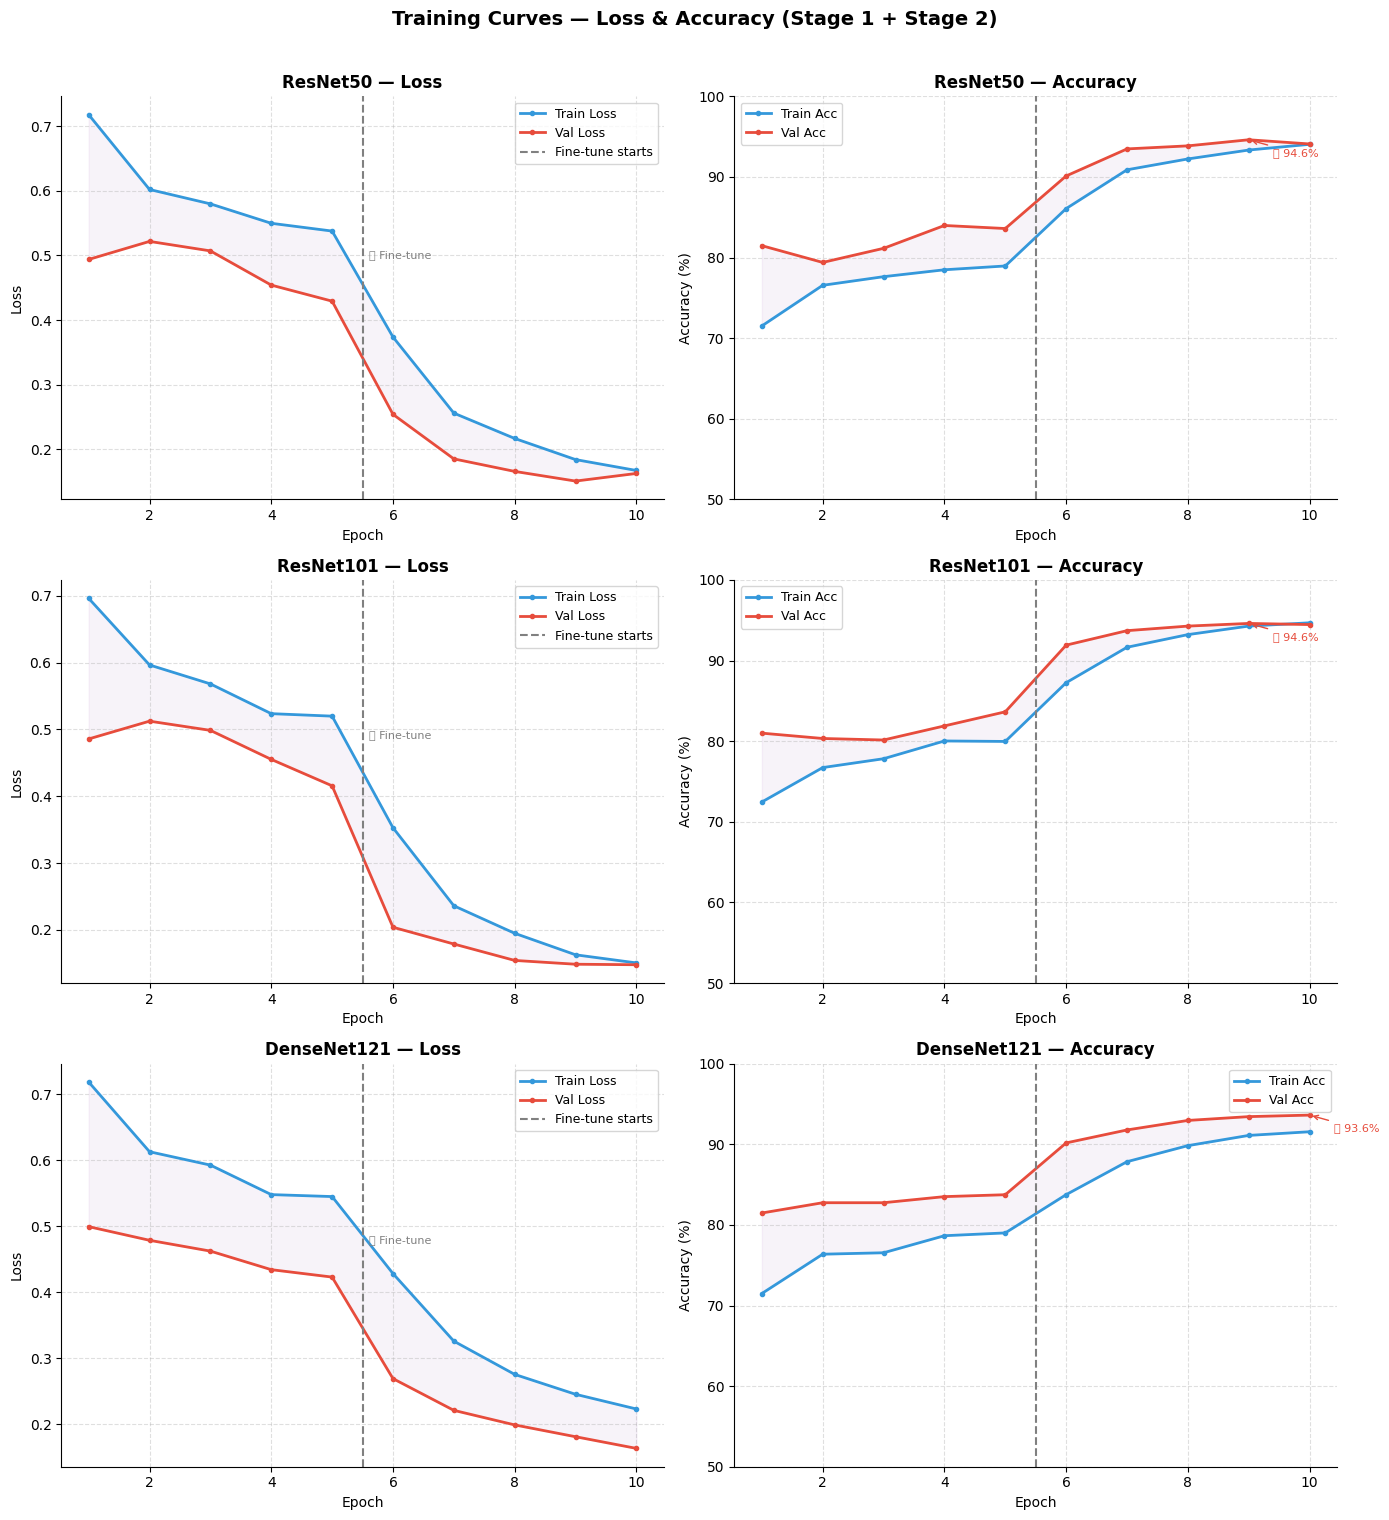

╔══════════════════════════════════════════════════════╗
║         📈  TRAINING CURVES COMPLETE                 ║
╠══════════════════════════════════════════════════════╣
║  Model           Best Train   Best Val  @ Epoch  ║
╠══════════════════════════════════════════════════════╣
║  ResNet50           94.05%     94.61%        9   ║
║  ResNet101          94.69%     94.61%        9   ║
║  DenseNet121        91.55%     93.62%       10   ║
╠══════════════════════════════════════════════════════╣
║  📉 Dashed line : Fine-tune stage begins            ║
║  🔵 Blue        : Training                          ║
║  🔴 Red         : Validation                        ║
║  ⭐ Star        : Best Val Accuracy point           ║
╠══════════════════════════════════════════════════════╣
║  💾 Saved → reports/training_curves.png             ║
╚══════════════════════════════════════════════════════╝


In [16]:
# ============================================================
#   CELL 9 — TRAINING CURVES
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(14, 15))
fig.suptitle("Training Curves — Loss & Accuracy (Stage 1 + Stage 2)",
             fontsize=14, fontweight="bold", y=1.01)

colors = {"train": "#3498db", "val": "#e74c3c"}

for i, (name, hist) in enumerate(ALL_HISTORIES.items()):
    epochs      = range(1, len(hist["train_loss"]) + 1)
    stage_split = EPOCHS_HEAD

    # ── Loss ──────────────────────────────────────────────────
    ax_loss = axes[i][0]
    ax_loss.plot(epochs, hist["train_loss"], color=colors["train"],
                 linewidth=2, marker="o", markersize=3, label="Train Loss")
    ax_loss.plot(epochs, hist["val_loss"],   color=colors["val"],
                 linewidth=2, marker="o", markersize=3, label="Val Loss")
    ax_loss.axvline(x=stage_split + 0.5, color="gray",
                    linestyle="--", linewidth=1.5, label="Fine-tune starts")
    ax_loss.fill_between(epochs, hist["train_loss"], hist["val_loss"],
                         alpha=0.07, color="#9b59b6")
    ax_loss.set_title(f"{name} — Loss", fontweight="bold")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.legend(fontsize=9)
    ax_loss.grid(linestyle="--", alpha=0.4)
    ax_loss.spines[["top","right"]].set_visible(False)
    ax_loss.annotate("🔥 Fine-tune",
                     xy=(stage_split + 0.6, max(hist["val_loss"]) * 0.95),
                     fontsize=8, color="gray")

    # ── Accuracy ──────────────────────────────────────────────
    ax_acc = axes[i][1]
    t_accs = [a * 100 for a in hist["train_acc"]]
    v_accs = [a * 100 for a in hist["val_acc"]]
    ax_acc.plot(epochs, t_accs, color=colors["train"],
                linewidth=2, marker="o", markersize=3, label="Train Acc")
    ax_acc.plot(epochs, v_accs, color=colors["val"],
                linewidth=2, marker="o", markersize=3, label="Val Acc")
    ax_acc.axvline(x=stage_split + 0.5, color="gray",
                   linestyle="--", linewidth=1.5)
    ax_acc.fill_between(epochs, t_accs, v_accs, alpha=0.07, color="#9b59b6")

    # Mark best val acc point
    best_epoch = v_accs.index(max(v_accs)) + 1
    ax_acc.annotate(f"⭐ {max(v_accs):.1f}%",
                    xy=(best_epoch, max(v_accs)),
                    xytext=(best_epoch + 0.4, max(v_accs) - 2),
                    fontsize=8, color="#e74c3c",
                    arrowprops=dict(arrowstyle="->", color="#e74c3c", lw=1))

    ax_acc.set_title(f"{name} — Accuracy", fontweight="bold")
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Accuracy (%)")
    ax_acc.set_ylim(50, 100)
    ax_acc.legend(fontsize=9)
    ax_acc.grid(linestyle="--", alpha=0.4)
    ax_acc.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"{REPORTS}/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Console Output ────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════╗")
print("║         📈  TRAINING CURVES COMPLETE                 ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  {'Model':<14} {'Best Train':>11} {'Best Val':>10} {'@ Epoch':>8}  ║")
print("╠══════════════════════════════════════════════════════╣")
for name, hist in ALL_HISTORIES.items():
    best_t   = max(hist["train_acc"]) * 100
    best_v   = max(hist["val_acc"])   * 100
    best_ep  = hist["val_acc"].index(max(hist["val_acc"])) + 1
    print(f"║  {name:<14} {best_t:>9.2f}%  {best_v:>8.2f}%  {best_ep:>7}   ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  📉 Dashed line : Fine-tune stage begins            ║")
print(f"║  🔵 Blue        : Training                          ║")
print(f"║  🔴 Red         : Validation                        ║")
print(f"║  ⭐ Star        : Best Val Accuracy point           ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  💾 Saved → reports/training_curves.png             ║")
print("╚══════════════════════════════════════════════════════╝")

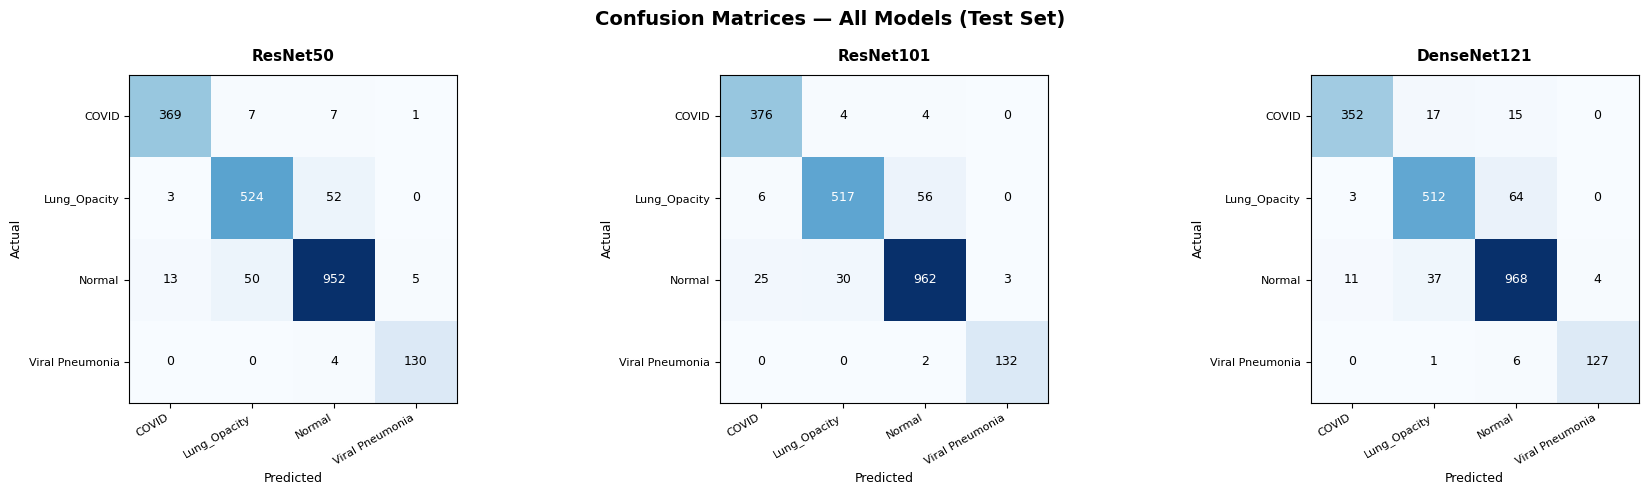

╔══════════════════════════════════════════════════════════════╗
║           🔲  CONFUSION MATRICES COMPLETE                    ║
╠══════════════════════════════════════════════════════════════╣
║  Model             Correct   Total      Acc          ║
╠══════════════════════════════════════════════════════════════╣
║  🧠 ResNet50          1975    2117   93.29%  █████████████░░ ║
║  🧠 ResNet101         1987    2117   93.86%  ██████████████░ ║
║  🧠 DenseNet121       1959    2117   92.54%  █████████████░░ ║
╠══════════════════════════════════════════════════════════════╣
║  📌 Rows  = Actual Class                                     ║
║  📌 Cols  = Predicted Class                                  ║
║  📌 Diag  = Correct Predictions                              ║
╠══════════════════════════════════════════════════════════════╣
║  📦 cms dict stored → used in Cell 11                       ║
║  💾 Saved → reports/confusion_matrices.png                  ║
╚═══════════════════════════════════════════

In [17]:
# ============================================================
#   CELL 10 — CONFUSION MATRICES
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import itertools

def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            outputs = model(images)
            preds   = outputs.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

def plot_confusion_matrix(ax, cm, title):
    ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.set_title(title, fontweight="bold", fontsize=11, pad=10)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right", fontsize=8)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8)
    ax.set_xlabel("Predicted", fontsize=9)
    ax.set_ylabel("Actual",    fontsize=9)
    thresh = cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        ax.text(j, i, f"{cm[i,j]}",
                ha="center", va="center", fontsize=9,
                color="white" if cm[i,j] > thresh else "black")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices — All Models (Test Set)",
             fontsize=14, fontweight="bold")

cms = {}
for i, (name, (model, _, _)) in enumerate(TRAINED_MODELS.items()):
    y_true, y_pred = get_predictions(model, test_loader)
    cm = confusion_matrix(y_true, y_pred)
    cms[name] = (cm, y_true, y_pred)   # store y_true/y_pred for Cell 11
    plot_confusion_matrix(axes[i], cm, name)

plt.tight_layout()
plt.savefig(f"{REPORTS}/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Console Output ────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════════════╗")
print("║           🔲  CONFUSION MATRICES COMPLETE                    ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  {'Model':<16} {'Correct':>8} {'Total':>7} {'Acc':>8}          ║")
print("╠══════════════════════════════════════════════════════════════╣")
for name, (cm, _, _) in cms.items():
    correct = np.trace(cm)
    total   = cm.sum()
    acc     = correct / total * 100
    bar_len = int(acc / 100 * 15)
    bar     = "█" * bar_len + "░" * (15 - bar_len)
    print(f"║  🧠 {name:<14} {correct:>7}  {total:>6}  {acc:>6.2f}%  {bar} ║")
print("╠══════════════════════════════════════════════════════════════╣")
print("║  📌 Rows  = Actual Class                                     ║")
print("║  📌 Cols  = Predicted Class                                  ║")
print("║  📌 Diag  = Correct Predictions                              ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  📦 cms dict stored → used in Cell 11                       ║")
print(f"║  💾 Saved → reports/confusion_matrices.png                  ║")
print("╚══════════════════════════════════════════════════════════════╝")

In [18]:
# ============================================================
#   CELL 11 — PER-CLASS CLASSIFICATION REPORTS
# ============================================================
import pandas as pd
from sklearn.metrics import classification_report

all_reports = {}

for name, (cm, y_true, y_pred) in cms.items():
    report = classification_report(
        y_true, y_pred,
        target_names=CLASS_NAMES,
        output_dict=True
    )
    all_reports[name] = report

    # ── Per model box ─────────────────────────────────────────
    print("╔══════════════════════════════════════════════════════════════════════╗")
    print(f"║  🧠 CLASSIFICATION REPORT — {name:<43}║")
    print("╠══════════════╦═════════════╦════════════╦══════════════╦════════════╣")
    print("║  Class       ║  Precision  ║   Recall   ║   F1-Score   ║  Support   ║")
    print("╠══════════════╬═════════════╬════════════╬══════════════╬════════════╣")

    for cls in CLASS_NAMES:
        p  = report[cls]["precision"] * 100
        r  = report[cls]["recall"]    * 100
        f1 = report[cls]["f1-score"]  * 100
        s  = int(report[cls]["support"])
        print(f"║  {cls:<12}  ║  {p:>7.2f}%   ║  {r:>6.2f}%  ║   {f1:>7.2f}%    ║  {s:>8}  ║")

    print("╠══════════════╬═════════════╬════════════╬══════════════╬════════════╣")
    ma_p  = report["macro avg"]["precision"]  * 100
    ma_r  = report["macro avg"]["recall"]     * 100
    ma_f1 = report["macro avg"]["f1-score"]   * 100
    wa_f1 = report["weighted avg"]["f1-score"]* 100
    acc   = report["accuracy"]                * 100

    print(f"║  {'Macro Avg':<12}  ║  {ma_p:>7.2f}%   ║  {ma_r:>6.2f}%  ║   {ma_f1:>7.2f}%    ║            ║")
    print(f"║  {'Weighted Avg':<12}  ║             ║            ║   {wa_f1:>7.2f}%    ║            ║")
    print("╠══════════════╩═════════════╩════════════╩══════════════╩════════════╣")
    print(f"║  ✅ Overall Accuracy : {acc:.2f}%{' ' * (47 - len(f'{acc:.2f}%'))}║")
    print("╚══════════════════════════════════════════════════════════════════════╝\n")

# ── Save all reports to CSV ───────────────────────────────────
rows = []
for name, report in all_reports.items():
    for cls in CLASS_NAMES:
        rows.append({
            "Model"    : name,
            "Class"    : cls,
            "Precision": round(report[cls]["precision"], 4),
            "Recall"   : round(report[cls]["recall"],    4),
            "F1-Score" : round(report[cls]["f1-score"],  4),
            "Support"  : int(report[cls]["support"]),
        })

df_reports = pd.DataFrame(rows)
df_reports.to_csv(f"{REPORTS}/classification_reports.csv", index=False)

print("╔══════════════════════════════════════════════════════╗")
print("║     ✅  ALL CLASSIFICATION REPORTS COMPLETE          ║")
print("╠══════════════════════════════════════════════════════╣")
for name, report in all_reports.items():
    acc = report["accuracy"] * 100
    f1  = report["macro avg"]["f1-score"] * 100
    print(f"║  🧠 {name:<14}  Acc: {acc:.2f}%   F1: {f1:.2f}%   ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  💾 Saved → reports/classification_reports.csv      ║")
print("╚══════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════════════════╗
║  🧠 CLASSIFICATION REPORT — ResNet50                                   ║
╠══════════════╦═════════════╦════════════╦══════════════╦════════════╣
║  Class       ║  Precision  ║   Recall   ║   F1-Score   ║  Support   ║
╠══════════════╬═════════════╬════════════╬══════════════╬════════════╣
║  COVID         ║    95.84%   ║   96.09%  ║     95.97%    ║       384  ║
║  Lung_Opacity  ║    90.19%   ║   90.50%  ║     90.34%    ║       579  ║
║  Normal        ║    93.79%   ║   93.33%  ║     93.56%    ║      1020  ║
║  Viral Pneumonia  ║    95.59%   ║   97.01%  ║     96.30%    ║       134  ║
╠══════════════╬═════════════╬════════════╬══════════════╬════════════╣
║  Macro Avg     ║    93.85%   ║   94.24%  ║     94.04%    ║            ║
║  Weighted Avg  ║             ║            ║     93.29%    ║            ║
╠══════════════╩═════════════╩════════════╩══════════════╩════════════╣
║  ✅ Overall Accuracy : 93.29%               

/tmp/ipykernel_1015/3222318807.py:70: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1015/3222318807.py:71: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{REPORTS}/model_comparison.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


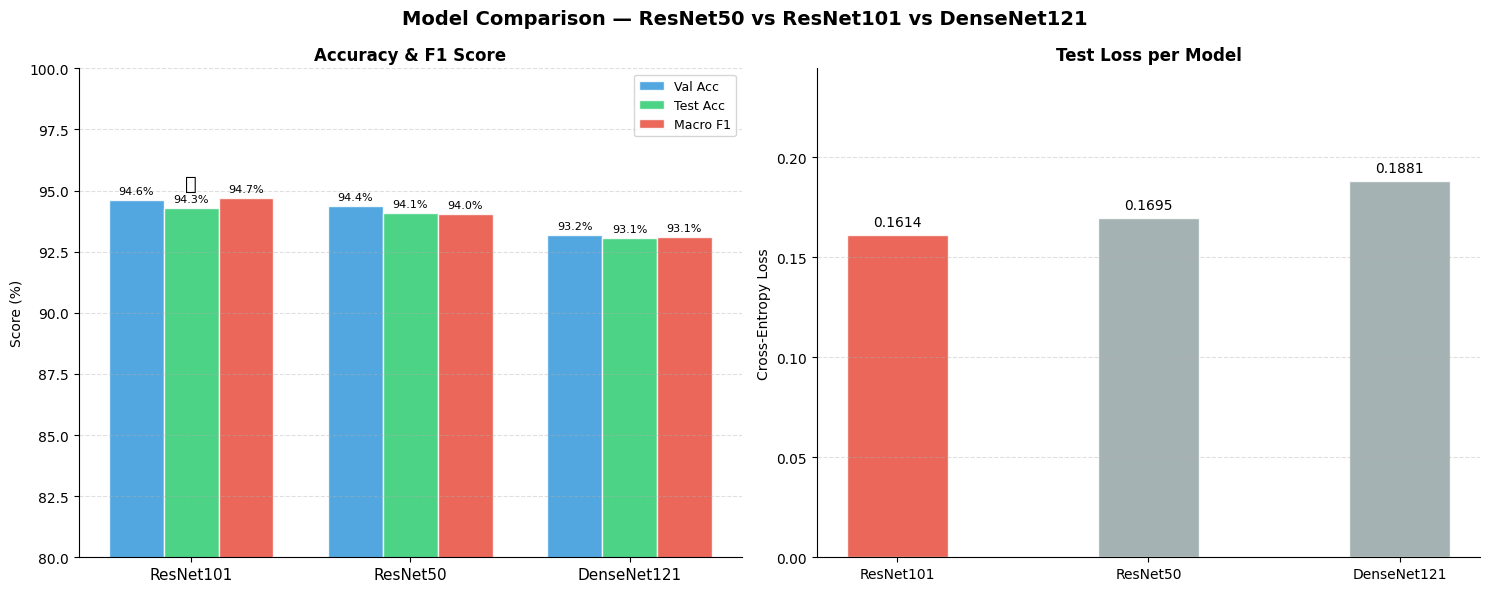

╔══════════════════════════════════════════════════════════════╗
║         📊  MODEL COMPARISON CHART COMPLETE                  ║
╠══════════════════════════════════════════════════════════════╣
║  Model            Val Acc   Test Acc       F1     Loss  ║
╠══════════════════════════════════════════════════════════════╣
║  🥇 ResNet101       94.61%    94.28%   94.71%  0.1614  ║
║  🥈 ResNet50        94.38%    94.10%   94.04%  0.1695  ║
║  🥉 DenseNet121     93.19%    93.06%   93.12%  0.1881  ║
╠══════════════════════════════════════════════════════════════╣
║  🏆 Best Model : ResNet101                                    ║
╠══════════════════════════════════════════════════════════════╣
║  💾 Saved → reports/model_comparison.png                    ║
╚══════════════════════════════════════════════════════════════╝


In [19]:
# ============================================================
#   CELL 12 — MODEL COMPARISON BAR CHART
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

models      = df_summary["Model"].tolist()
val_accs    = df_summary["Val Acc"].tolist()
test_accs   = df_summary["Test Acc"].tolist()
test_losses = df_summary["Test Loss"].tolist()

# F1 scores from classification reports
f1_scores = [all_reports[m]["macro avg"]["f1-score"] * 100 for m in models]

x     = np.arange(len(models))
width = 0.25
colors = ["#3498db", "#2ecc71", "#e74c3c"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Model Comparison — ResNet50 vs ResNet101 vs DenseNet121",
             fontsize=14, fontweight="bold")

# ── Left: Val Acc / Test Acc / F1 grouped bars ───────────────
bars1 = ax1.bar(x - width,   val_accs,   width, label="Val Acc",
                color=colors[0], alpha=0.85, edgecolor="white")
bars2 = ax1.bar(x,           test_accs,  width, label="Test Acc",
                color=colors[1], alpha=0.85, edgecolor="white")
bars3 = ax1.bar(x + width,   f1_scores,  width, label="Macro F1",
                color=colors[2], alpha=0.85, edgecolor="white")

ax1.set_title("Accuracy & F1 Score", fontweight="bold")
ax1.set_ylabel("Score (%)")
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=11)
ax1.set_ylim(80, 100)
ax1.legend(fontsize=9)
ax1.grid(axis="y", linestyle="--", alpha=0.4)
ax1.spines[["top","right"]].set_visible(False)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.15,
                 f"{bar.get_height():.1f}%",
                 ha="center", va="bottom", fontsize=8)

# Best model annotation
best_idx = test_accs.index(max(test_accs))
ax1.annotate("🏆",
             xy=(best_idx, max(test_accs) + 0.8),
             ha="center", fontsize=14)

# ── Right: Test Loss ──────────────────────────────────────────
bar_colors = ["#e74c3c" if m == BEST_MODEL_NAME else "#95a5a6" for m in models]
bars4 = ax2.bar(models, test_losses, color=bar_colors,
                alpha=0.85, edgecolor="white", width=0.4)

ax2.set_title("Test Loss per Model", fontweight="bold")
ax2.set_ylabel("Cross-Entropy Loss")
ax2.set_ylim(0, max(test_losses) * 1.3)
ax2.grid(axis="y", linestyle="--", alpha=0.4)
ax2.spines[["top","right"]].set_visible(False)

for bar in bars4:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.003,
             f"{bar.get_height():.4f}",
             ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig(f"{REPORTS}/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Console Output ────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════════════╗")
print("║         📊  MODEL COMPARISON CHART COMPLETE                  ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  {'Model':<14} {'Val Acc':>9} {'Test Acc':>10} {'F1':>8} {'Loss':>8}  ║")
print("╠══════════════════════════════════════════════════════════════╣")
medals = ["🥇","🥈","🥉"]
for i, row in df_summary.iterrows():
    f1 = all_reports[row["Model"]]["macro avg"]["f1-score"] * 100
    print(f"║  {medals[i]} {row['Model']:<13}"
          f"{row['Val Acc']:>8.2f}% "
          f"{row['Test Acc']:>8.2f}% "
          f"{f1:>7.2f}% "
          f"{row['Test Loss']:>7.4f}  ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  🏆 Best Model : {BEST_MODEL_NAME:<45}║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  💾 Saved → reports/model_comparison.png                    ║")
print("╚══════════════════════════════════════════════════════════════╝")

In [20]:
# ============================================================
#   CELL 13 — SAVE BEST MODEL
# ============================================================
import os, torch, json
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# ── Save best model weights ───────────────────────────────────
best_weight_path = f"{WEIGHTS}/{BEST_MODEL_NAME}_{timestamp}.pth"
torch.save(BEST_MODEL.state_dict(), best_weight_path)

# ── Save full checkpoint (weights + metadata) ─────────────────
checkpoint = {
    "model_name"  : BEST_MODEL_NAME,
    "state_dict"  : BEST_MODEL.state_dict(),
    "class_names" : CLASS_NAMES,
    "num_classes" : NUM_CLASSES,
    "img_size"    : 224,
    "timestamp"   : timestamp,
    "test_acc"    : float(df_summary.iloc[0]["Test Acc"]),
    "val_acc"     : float(df_summary.iloc[0]["Val Acc"]),
    "test_loss"   : float(df_summary.iloc[0]["Test Loss"]),
}
checkpoint_path = f"{WEIGHTS}/{BEST_MODEL_NAME}_checkpoint_{timestamp}.pth"
torch.save(checkpoint, checkpoint_path)

# ── Save model metadata as JSON ───────────────────────────────
meta = {
    "model_name"  : BEST_MODEL_NAME,
    "class_names" : CLASS_NAMES,
    "num_classes" : NUM_CLASSES,
    "img_size"    : 224,
    "timestamp"   : timestamp,
    "test_acc"    : float(df_summary.iloc[0]["Test Acc"]),
    "val_acc"     : float(df_summary.iloc[0]["Val Acc"]),
    "test_loss"   : float(df_summary.iloc[0]["Test Loss"]),
    "normalize"   : {
        "mean" : [0.485, 0.456, 0.406],
        "std"  : [0.229, 0.224, 0.225]
    }
}
meta_path = f"{WEIGHTS}/model_meta.json"
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=4)

# ── File sizes ────────────────────────────────────────────────
def file_mb(path):
    return os.path.getsize(path) / (1024 * 1024)

print("╔══════════════════════════════════════════════════════════════╗")
print("║              💾  BEST MODEL SAVED                            ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  🏆 Model      : {BEST_MODEL_NAME:<45}║")
print(f"║  ✅ Test Acc   : {df_summary.iloc[0]['Test Acc']:.2f}%{' '*44}║"[:66]+"║")
print(f"║  ✅ Val Acc    : {df_summary.iloc[0]['Val Acc']:.2f}%{' '*44}║"[:66]+"║")
print(f"║  📉 Test Loss  : {df_summary.iloc[0]['Test Loss']:.4f}{' '*44}║"[:66]+"║")
print("╠══════════════════════════════════════════════════════════════╣")
print("║  📁 Files Saved :                                            ║")
print(f"║   → {BEST_MODEL_NAME}_{timestamp}.pth")
print(f"║     Size : {file_mb(best_weight_path):.1f} MB")
print(f"║   → {BEST_MODEL_NAME}_checkpoint_{timestamp}.pth")
print(f"║     Size : {file_mb(checkpoint_path):.1f} MB")
print(f"║   → model_meta.json")
print("╠══════════════════════════════════════════════════════════════╣")
print("║  📌 Checkpoint contains:                                     ║")
print("║     state_dict │ class_names │ img_size │ metrics            ║")
print("║  📌 JSON meta  : use for inference without loading model     ║")
print("╠══════════════════════════════════════════════════════════════╣")

# ── How to reload ─────────────────────────────────────────────
print("║  🔁 To Reload:                                               ║")
print("║     ckpt  = torch.load(checkpoint_path)                      ║")
print("║     model = build_<modelname>(num_classes=4)                 ║")
print("║     model.load_state_dict(ckpt['state_dict'])                ║")
print("║     model.eval()                                             ║")
print("╚══════════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════════╗
║              💾  BEST MODEL SAVED                            ║
╠══════════════════════════════════════════════════════════════╣
║  🏆 Model      : ResNet101                                    ║
║  ✅ Test Acc   : 94.28%                                          ║
║  ✅ Val Acc    : 94.61%                                          ║
║  📉 Test Loss  : 0.1614                                          ║
╠══════════════════════════════════════════════════════════════╣
║  📁 Files Saved :                                            ║
║   → ResNet101_20260419_084538.pth
║     Size : 164.7 MB
║   → ResNet101_checkpoint_20260419_084538.pth
║     Size : 164.7 MB
║   → model_meta.json
╠══════════════════════════════════════════════════════════════╣
║  📌 Checkpoint contains:                                     ║
║     state_dict │ class_names │ img_size │ metrics            ║
║  📌 JSON meta  : use for inference without loading model     ║
╠

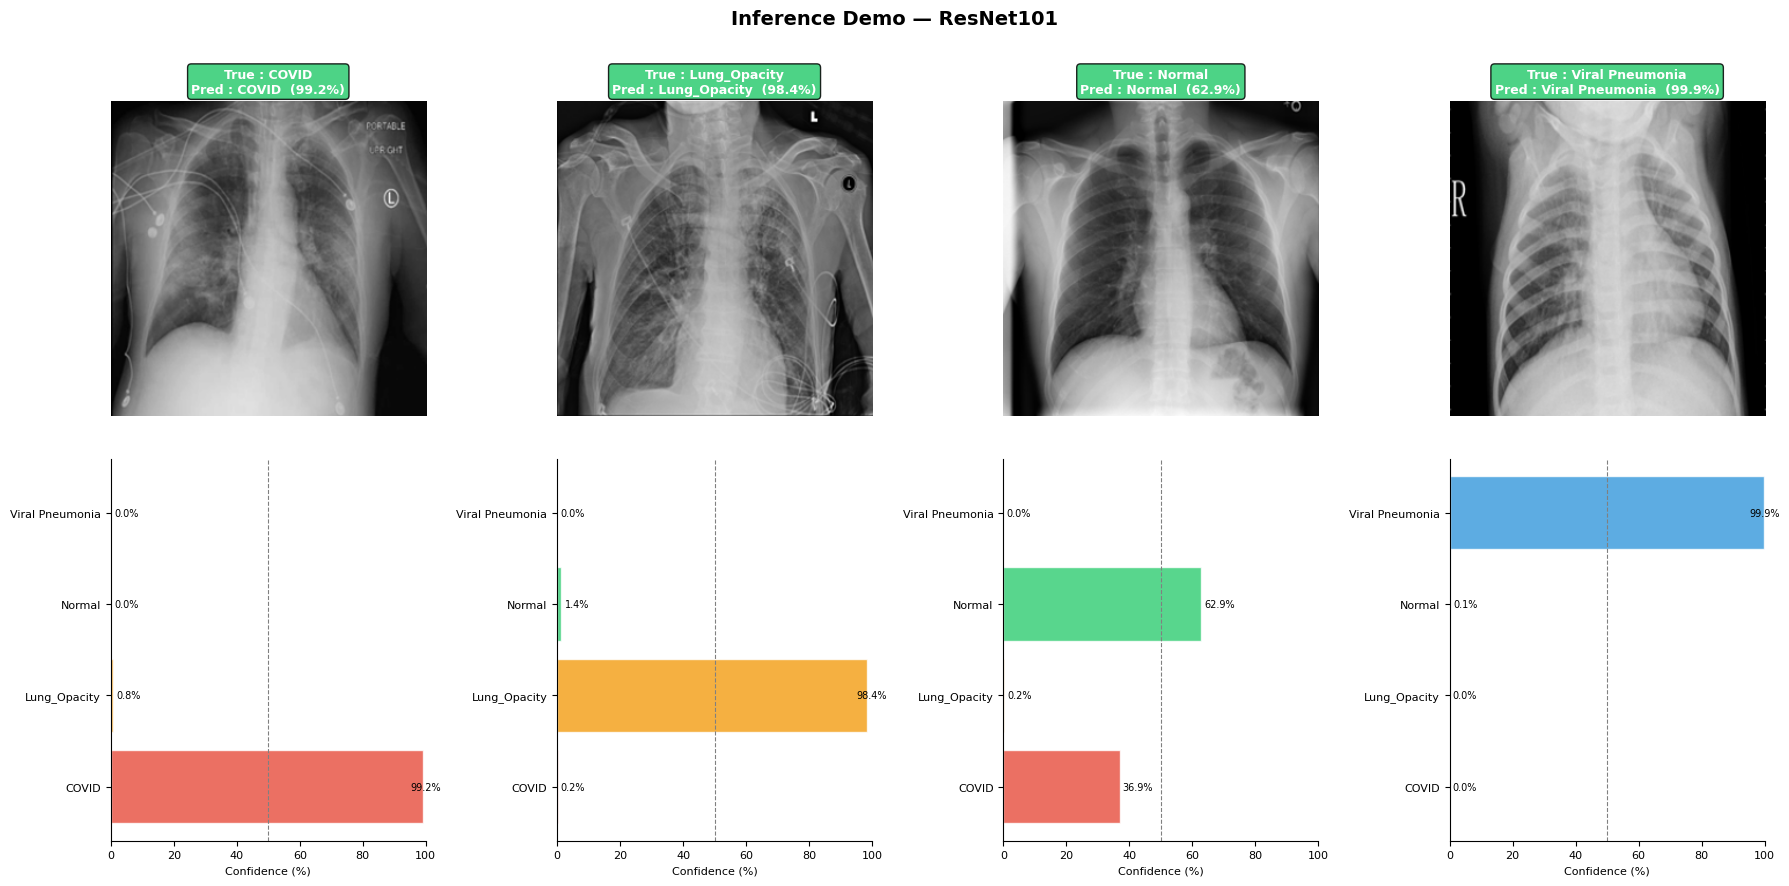

╔══════════════════════════════════════════════════════════════╗
║        🔍  INFERENCE DEMO — ResNet101                         ║
╠══════════════════════════════════════════════════════════════╣
║  True Label         Predicted              Conf   Result  ║
╠══════════════════════════════════════════════════════════════╣
║  COVID              COVID                99.2%  ✅ Correct ║
║  Lung_Opacity       Lung_Opacity         98.4%  ✅ Correct ║
║  Normal             Normal               62.9%  ✅ Correct ║
║  Viral Pneumonia    Viral Pneumonia      99.9%  ✅ Correct ║
╠══════════════════════════════════════════════════════════════╣
║  ✅ Correct : 4/4                                                ║
╠══════════════════════════════════════════════════════════════╣
║  💾 Saved → reports/inference_demo.png                      ║
╚══════════════════════════════════════════════════════════════╝


In [21]:
# ============================================================
#   CELL 14 — SINGLE IMAGE INFERENCE DEMO
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import torch, os, random
import torch.nn.functional as F

# ── Inference transform (no augmentation) ────────────────────
infer_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def predict_image(img_path, model):
    model.eval()
    img    = Image.open(img_path).convert("RGB")
    tensor = infer_transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        output = model(tensor)
        probs  = F.softmax(output, dim=1).squeeze().cpu().numpy()
    pred_idx   = probs.argmax()
    pred_label = CLASS_NAMES[pred_idx]
    confidence = probs[pred_idx] * 100
    return img, pred_label, confidence, probs

# ── Pick one random image per class ──────────────────────────
CLASS_COLORS = {
    "COVID"           : "#e74c3c",
    "Lung_Opacity"    : "#f39c12",
    "Normal"          : "#2ecc71",
    "Viral Pneumonia" : "#3498db"
}

sample_images = []
for cls in CLASS_NAMES:
    img_dir = os.path.join(DATA_PATH, cls, "images")
    if not os.path.exists(img_dir):
        img_dir = os.path.join(DATA_PATH, cls)
    fname = random.choice(os.listdir(img_dir))
    sample_images.append((os.path.join(img_dir, fname), cls))

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle(f"Inference Demo — {BEST_MODEL_NAME}",
             fontsize=14, fontweight="bold")

results = []
for i, (img_path, true_label) in enumerate(sample_images):
    img, pred_label, confidence, probs = predict_image(img_path, BEST_MODEL)

    correct = pred_label == true_label
    color   = "#2ecc71" if correct else "#e74c3c"

    # ── Image ─────────────────────────────────────────────────
    ax_img = axes[0][i]
    ax_img.imshow(img, cmap="gray")
    ax_img.set_title(
        f"True : {true_label}\nPred : {pred_label}  ({confidence:.1f}%)",
        fontsize=9, fontweight="bold",
        color="white",
        bbox=dict(boxstyle="round,pad=0.3", facecolor=color, alpha=0.85)
    )
    ax_img.axis("off")

    # ── Probability bar ───────────────────────────────────────
    ax_bar = axes[1][i]
    bar_colors = [CLASS_COLORS[c] for c in CLASS_NAMES]
    bars = ax_bar.barh(CLASS_NAMES, probs * 100,
                       color=bar_colors, alpha=0.8, edgecolor="white")
    ax_bar.set_xlim(0, 100)
    ax_bar.set_xlabel("Confidence (%)", fontsize=8)
    ax_bar.axvline(x=50, color="gray", linestyle="--", linewidth=0.8)
    ax_bar.spines[["top","right"]].set_visible(False)
    ax_bar.tick_params(labelsize=8)
    for bar, prob in zip(bars, probs):
        ax_bar.text(min(prob*100 + 1, 95), bar.get_y() + bar.get_height()/2,
                    f"{prob*100:.1f}%", va="center", fontsize=7)

    results.append({
        "true": true_label, "pred": pred_label,
        "conf": confidence, "correct": correct
    })

plt.tight_layout()
plt.savefig(f"{REPORTS}/inference_demo.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Console Output ────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════════════╗")
print(f"║        🔍  INFERENCE DEMO — {BEST_MODEL_NAME:<34}║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  {'True Label':<18} {'Predicted':<18} {'Conf':>8} {'Result':>8}  ║")
print("╠══════════════════════════════════════════════════════════════╣")
for r in results:
    status = "✅ Correct" if r["correct"] else "❌ Wrong"
    print(f"║  {r['true']:<18} {r['pred']:<18} {r['conf']:>6.1f}%  {status:<10}║")
print("╠══════════════════════════════════════════════════════════════╣")
correct_count = sum(r["correct"] for r in results)
print(f"║  ✅ Correct : {correct_count}/{len(results)}{' '*48}║"[:66]+"║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  💾 Saved → reports/inference_demo.png                      ║")
print("╚══════════════════════════════════════════════════════════════╝")